# ArUco Detector Stability

Visualize continuous rotation logs from `aruco_test.py`.
The angle should ramp smoothly as the robot spins. Any sudden 90° jumps = detector glitch.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

LOG_DIR = Path("../aruco_logs")
csv_files = sorted(LOG_DIR.glob("*.csv"))
csv_path = csv_files[-1] if csv_files else None
print(f"Loading: {csv_path}")

df = pd.read_csv(csv_path)
df["aruco_angle"] = pd.to_numeric(df["aruco_angle"], errors="coerce")
df["aruco_id"] = pd.to_numeric(df["aruco_id"], errors="coerce")

detected = df[df["aruco_angle"].notna()]
missed = df[df["aruco_angle"].isna()]
print(f"{len(df)} frames total, {len(detected)} with aruco, {len(missed)} missed")
df.head()

Loading: ../aruco_logs/2026-03-16_184338.csv
3716 frames total, 3708 with aruco, 8 missed


,t,frame,aruco_id,aruco_angle,center_x,center_y,line_0,line_90,line_180,line_270,blue_line
0,18:43:39.612,1,0.0,272.0,264.9,353.6,-87.99,2.01,-87.99,2.01,1.60
1,18:43:39.639,2,0.0,272.2,264.8,353.7,-87.75,2.25,-87.75,2.25,1.59
2,18:43:39.655,3,0.0,271.8,264.9,353.5,-88.24,1.76,-88.24,1.76,1.58
3,18:43:39.666,4,0.0,272.2,264.7,353.7,-87.84,2.16,-87.84,2.16,1.59
4,18:43:39.677,5,0.0,272.2,264.7,353.7,-87.80,2.20,-87.80,2.20,1.76


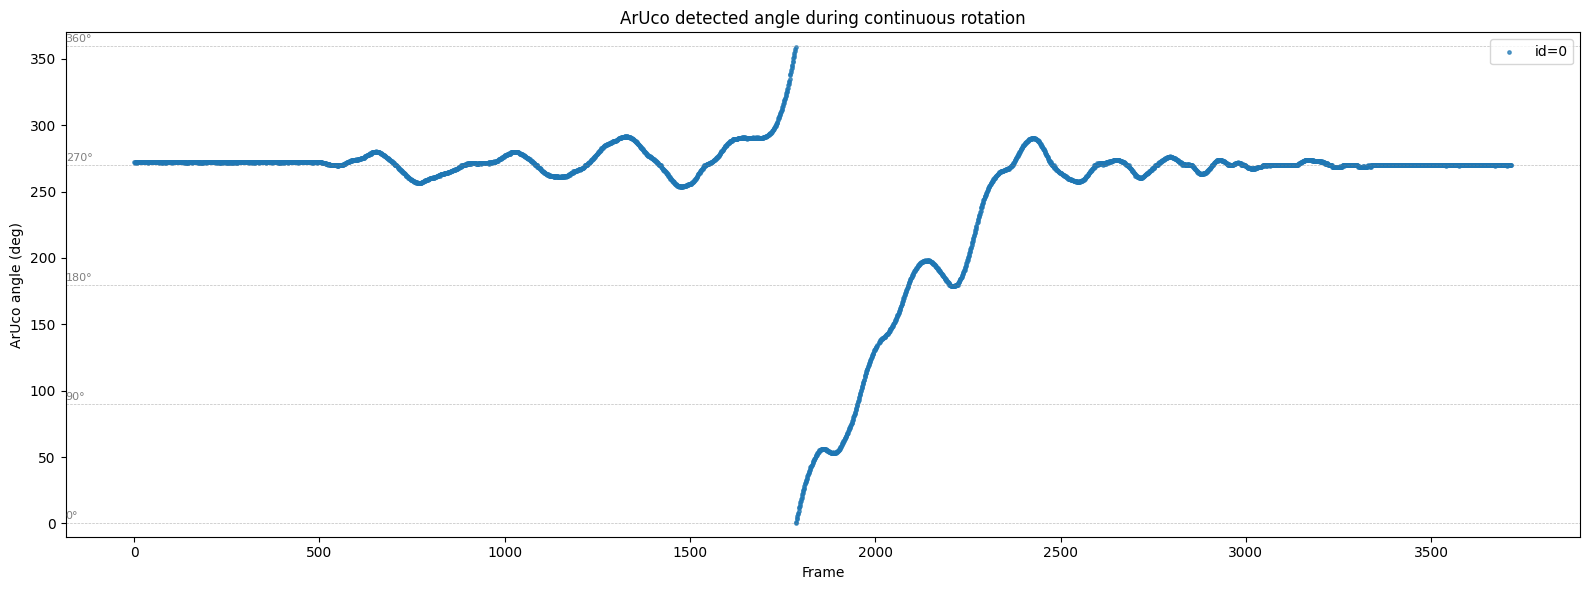

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))

# Plot by marker ID
unique_ids = sorted(detected["aruco_id"].dropna().unique())
for mid in unique_ids:
    mask = detected["aruco_id"] == mid
    ax.scatter(detected.loc[mask, "frame"], detected.loc[mask, "aruco_angle"],
               s=6, alpha=0.7, label=f"id={int(mid)}")

# Reference lines at 90° intervals
for deg in [0, 90, 180, 270, 360]:
    ax.axhline(deg, color="gray", ls="--", lw=0.5, alpha=0.5)
    ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] != 0 else 0, deg + 3,
            f"{deg}°", fontsize=8, color="gray")

# Highlight glitches: points where angle jumps >45° from neighbors
angles = detected["aruco_angle"].values
frames = detected["frame"].values
if len(angles) > 2:
    # Compute angular distance to previous point (handling 0/360 wrap)
    diff = np.abs(np.diff(angles))
    diff = np.minimum(diff, 360 - diff)
    glitch_mask = diff > 45
    glitch_idx = np.where(glitch_mask)[0] + 1  # +1 because diff shifts by 1
    if len(glitch_idx) > 0:
        ax.scatter(frames[glitch_idx], angles[glitch_idx],
                   s=60, facecolors="none", edgecolors="red", lw=1.5,
                   label=f"glitch (>45° jump, n={len(glitch_idx)})")

ax.set_xlabel("Frame")
ax.set_ylabel("ArUco angle (deg)")
ax.set_title("ArUco detected angle during continuous rotation")
ax.set_ylim(-10, 370)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

if len(angles) > 2 and len(glitch_idx) > 0:
    print(f"\n{len(glitch_idx)} glitches detected:")
    for gi in glitch_idx[:20]:
        row = detected.iloc[gi]
        prev = detected.iloc[gi - 1]
        print(f"  frame {int(row['frame'])}: {prev['aruco_angle']:.1f}° → {row['aruco_angle']:.1f}°  "
              f"(jump={diff[gi-1]:.1f}°, id={int(row['aruco_id'])})")

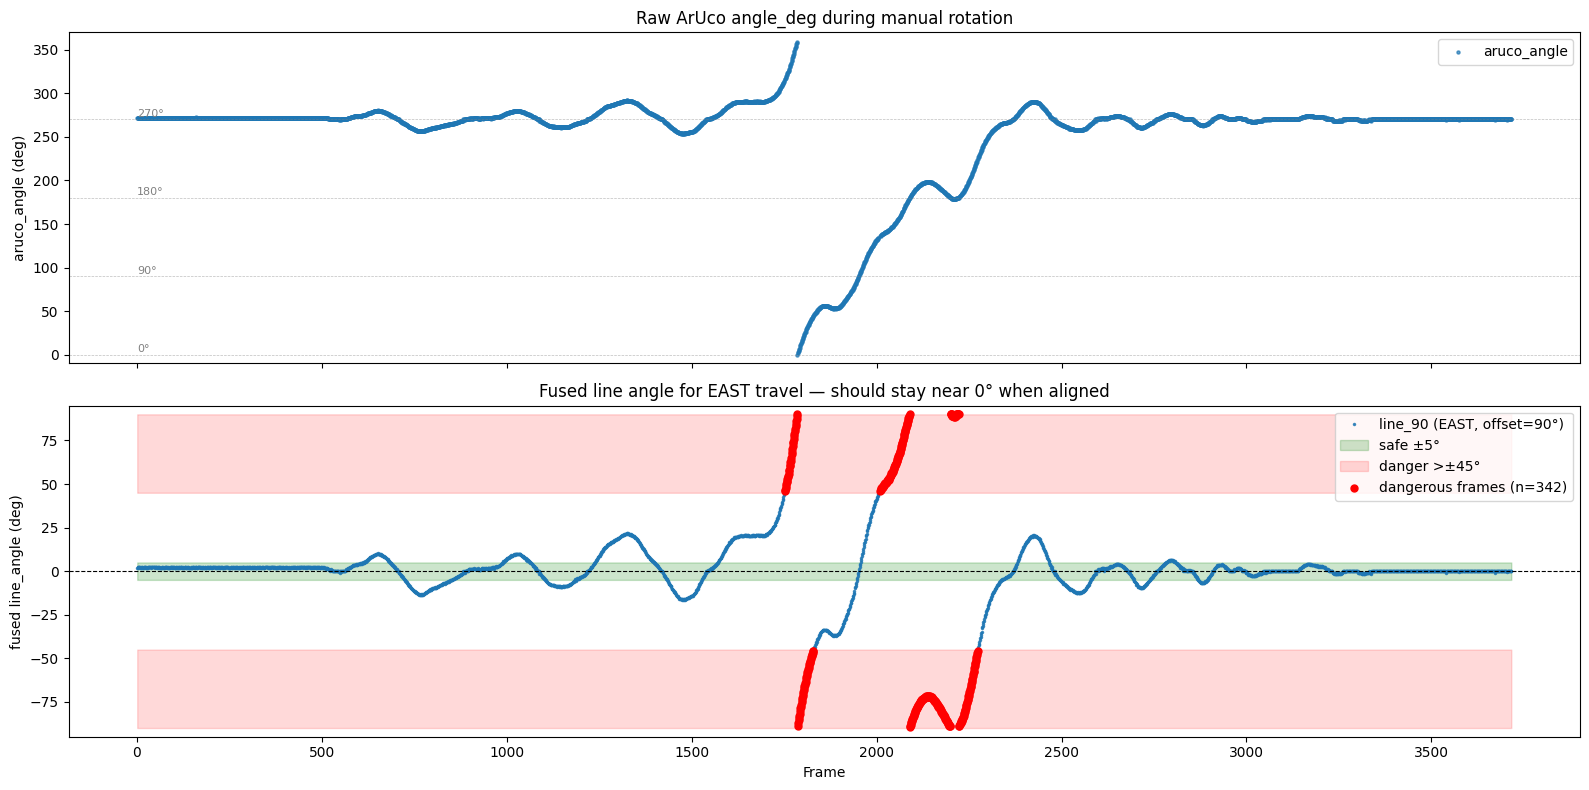


EAST fusion: 342 dangerous frames out of 3708 (9.2%)
Dangerous aruco angles (what raw angle triggers bad fusion):
 frame  aruco_angle  line_90
  1752        316.1    46.12
  1753        316.8    46.85
  1754        318.0    48.01
  1755        319.0    49.04
  1756        319.9    49.90
  1757        320.9    50.91
  1758        322.0    52.00
  1759        322.8    52.84
  1760        324.3    54.29
  1761        324.9    54.90
  1762        326.0    56.04
  1763        327.3    57.32
  1764        328.3    58.32
  1765        330.1    60.12
  1766        331.2    61.19
  1767        332.4    62.45
  1768        333.4    63.43
  1769        334.8    64.80
  1770        337.5    67.52
  1771        338.5    68.52
  1772        340.1    70.10
  1773        341.6    71.57
  1774        343.3    73.30
  1775        344.3    74.32
  1776        345.7    75.74
  1777        347.4    77.37
  1778        348.7    78.69
  1779        350.5    80.54
  1780        351.7    81.74
  1781        3

In [6]:
# Focused 2-panel view: raw aruco_angle vs fused line_90 (EAST facing)
# This mirrors exactly what app.py sees during an EAST move (heading_offset=90)

if "line_90" not in df.columns:
    print("No fusion columns in this log — run aruco_test.py again to get updated data.")
else:
    df["line_90"] = pd.to_numeric(df["line_90"], errors="coerce")
    det = df[df["aruco_angle"].notna()].copy()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    # --- Top: raw aruco_angle ---
    ax1.scatter(det["frame"], det["aruco_angle"], s=5, alpha=0.7, label="aruco_angle")
    for deg in [0, 90, 180, 270]:
        ax1.axhline(deg, color="gray", ls="--", lw=0.5, alpha=0.5)
        ax1.text(det["frame"].iloc[0], deg + 3, f"{deg}°", fontsize=8, color="gray")

    # Highlight jumps > 45°
    if len(det) > 2:
        angles = det["aruco_angle"].values
        frames = det["frame"].values
        diff = np.abs(np.diff(angles))
        diff = np.minimum(diff, 360 - diff)
        glitch_idx = np.where(diff > 45)[0] + 1
        if len(glitch_idx):
            ax1.scatter(frames[glitch_idx], angles[glitch_idx],
                        s=60, facecolors="none", edgecolors="red", lw=1.5,
                        label=f"jump >45° (n={len(glitch_idx)})")

    ax1.set_ylim(-10, 370)
    ax1.set_ylabel("aruco_angle (deg)")
    ax1.set_title("Raw ArUco angle_deg during manual rotation")
    ax1.legend(loc="upper right")

    # --- Bottom: fused line_90 ---
    has_line = det["line_90"].notna()
    ax2.plot(det.loc[has_line, "frame"], det.loc[has_line, "line_90"],
             ".", ms=3, alpha=0.8, label="line_90 (EAST, offset=90°)")
    ax2.axhline(0, color="k", ls="--", lw=0.8)
    ax2.fill_between(det["frame"], -5, 5, alpha=0.2, color="green", label="safe ±5°")
    ax2.fill_between(det["frame"], 45, 90, alpha=0.15, color="red")
    ax2.fill_between(det["frame"], -90, -45, alpha=0.15, color="red", label="danger >±45°")

    bad = det[det["line_90"].abs() > 45]
    if len(bad):
        ax2.scatter(bad["frame"], bad["line_90"], s=25, c="red", zorder=5,
                    label=f"dangerous frames (n={len(bad)})")

    ax2.set_ylim(-95, 95)
    ax2.set_ylabel("fused line_angle (deg)")
    ax2.set_xlabel("Frame")
    ax2.set_title("Fused line angle for EAST travel — should stay near 0° when aligned")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    n_bad = det["line_90"].abs().gt(45).sum()
    n_total = det["line_90"].notna().sum()
    print(f"\nEAST fusion: {n_bad} dangerous frames out of {n_total} "
          f"({100*n_bad/max(n_total,1):.1f}%)")
    if n_bad:
        print("Dangerous aruco angles (what raw angle triggers bad fusion):")
        print(det.loc[det["line_90"].abs() > 45, ["frame","aruco_angle","line_90"]].to_string(index=False))
